In [3]:
import requests
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt
import seaborn as sns

### Fetching data from Toronto's Open Data Portal
convert the API data into a pandas DataFrame!

- Fetches metadata about the "parking-occupancy" dataset
- Loops through resources - datasets can have multiple files/tables
- Downloads active resources as CSV text
- Converts to DataFrame using pd.read_csv(StringIO(...)) - this reads CSV from a string instead of a file
- Displays info about each DataFrame

In [60]:
# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [61]:
# Fetch the data
base_url = "https://ckan0.cf.opendata.inter.prod-toronto.ca"
url = base_url + "/api/3/action/package_show"
params = {"id": "parking-occupancy"}
package = requests.get(url, params=params).json()

In [62]:
# Get the data
for resource in package["result"]["resources"]:
    if resource["datastore_active"]:
        url = base_url + "/datastore/dump/" + resource["id"]
        csv_data = requests.get(url).text
        df = pd.read_csv(StringIO(csv_data))
        break

In [63]:
# Display basic info
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nBasic statistics:")
print(df.describe())

Dataset shape: (465, 7)

Column names:
['_id', 'Car Park Number', 'Car Park Location', 'Total Available Spaces', 'Average Daily Peak Occupancy %', 'Year', 'Quarter']

First few rows:
   _id Car Park Number  Car Park Location  Total Available Spaces  \
0    1             CP1    20 Charles St E                     646   
1    2             CP3     13 Isabella St                      30   
2    3             CP5  15 Wellesley St E                     126   
3    4            CP13     10 Delisle Ave                     240   
4    5            CP17       716 Pape Ave                      74   

  Average Daily Peak Occupancy %  Year Quarter  
0                            26%  2024     NaN  
1                            93%  2024     NaN  
2                            53%  2024     NaN  
3                            26%  2024     NaN  
4                            82%  2024     NaN  

Data types:
_id                                int64
Car Park Number                   object
Car Park Loca

### Parking Occupancy Dataset

| Column | Description |
|--------|-------------|
| _id | Unique row identifier for Open Data database |
| Car Park Number | Unique identifier for each parking facility |
| Car Park Location | Address of the car park |
| Total Available Spaces | Count of spaces available for parking |
| Average Daily Peak Occupancy % | Average daily peak occupancy is the primary utilization metric employed by TPA. It is derived from paid parking transactions and calculated by taking the highest number of transactions recorded each day, dividing by location capacity to get a daily peak percentage, then averaging these percentages over the total number of days in the reported period (e.g., 90 days for a quarterly report) |
| Year | Year of this record |
| Quarter | Quarter of this record |

In [64]:
# ============================================
# First VISUALIZATION: Bar Chart
# Average Occupancy by Year
# ============================================

# Clean the data
df['Average Daily Peak Occupancy %'] = df['Average Daily Peak Occupancy %'].str.rstrip('%').astype(float)

In [65]:
df.head()

,_id,Car Park Number,Car Park Location,Total Available Spaces,Average Daily Peak Occupancy %,Year,Quarter
0,1,CP1,20 Charles St E,646,26.0,2024,NaN
1,2,CP3,13 Isabella St,30,93.0,2024,NaN
2,3,CP5,15 Wellesley St E,126,53.0,2024,NaN
3,4,CP13,10 Delisle Ave,240,26.0,2024,NaN
4,5,CP17,716 Pape Ave,74,82.0,2024,NaN


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465 entries, 0 to 464
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   _id                             465 non-null    int64  
 1   Car Park Number                 465 non-null    object 
 2   Car Park Location               465 non-null    object 
 3   Total Available Spaces          465 non-null    int64  
 4   Average Daily Peak Occupancy %  465 non-null    float64
 5   Year                            465 non-null    int64  
 6   Quarter                         311 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 25.6+ KB


In [67]:
df.rename(columns={
    'Car Park Number': 'park_id',
    'Car Park Location': 'location',
    'Total Available Spaces': 'total_spaces',
    'Average Daily Peak Occupancy %': 'avg_peak'
}, inplace=True)

In [68]:
# Use 2024 data (full year data without quarters)
df_2024 = df[df['Year'] == 2024].copy()

In [69]:
df_2024

,_id,park_id,location,total_spaces,avg_peak,Year,Quarter
0,1,CP1,20 Charles St E,646,26.0,2024,NaN
1,2,CP3,13 Isabella St,30,93.0,2024,NaN
2,3,CP5,15 Wellesley St E,126,53.0,2024,NaN
3,4,CP13,10 Delisle Ave,240,26.0,2024,NaN
4,5,CP17,716 Pape Ave,74,82.0,2024,NaN
...,...,...,...,...,...,...,...
149,150,CP674,2623 Eglinton Ave W,12,36.0,2024,NaN
150,151,CP700,101 Grangeway Ave,255,4.0,2024,NaN
151,152,CP701,197 Blantyre Ave,83,46.0,2024,NaN
152,153,CP706,284 Milner Ave,92,18.0,2024,NaN


In [70]:
print("Calculating key statistics...")
total = len(df_2024)
low_moderate = len(df_2024[df_2024['avg_peak'] < 75])
high_demand = len(df_2024[df_2024['avg_peak'] >= 75])

print(f"Total facilities: {total}")
print(f"Low/Moderate (<75%): {low_moderate} ({low_moderate/total*100:.0f}%)")
print(f"High-demand (≥75%): {high_demand} ({high_demand/total*100:.0f}%)")

Calculating key statistics...
Total facilities: 154
Low/Moderate (<75%): 107 (69%)
High-demand (≥75%): 47 (31%)



✓ Histogram saved: Grouped with annotations


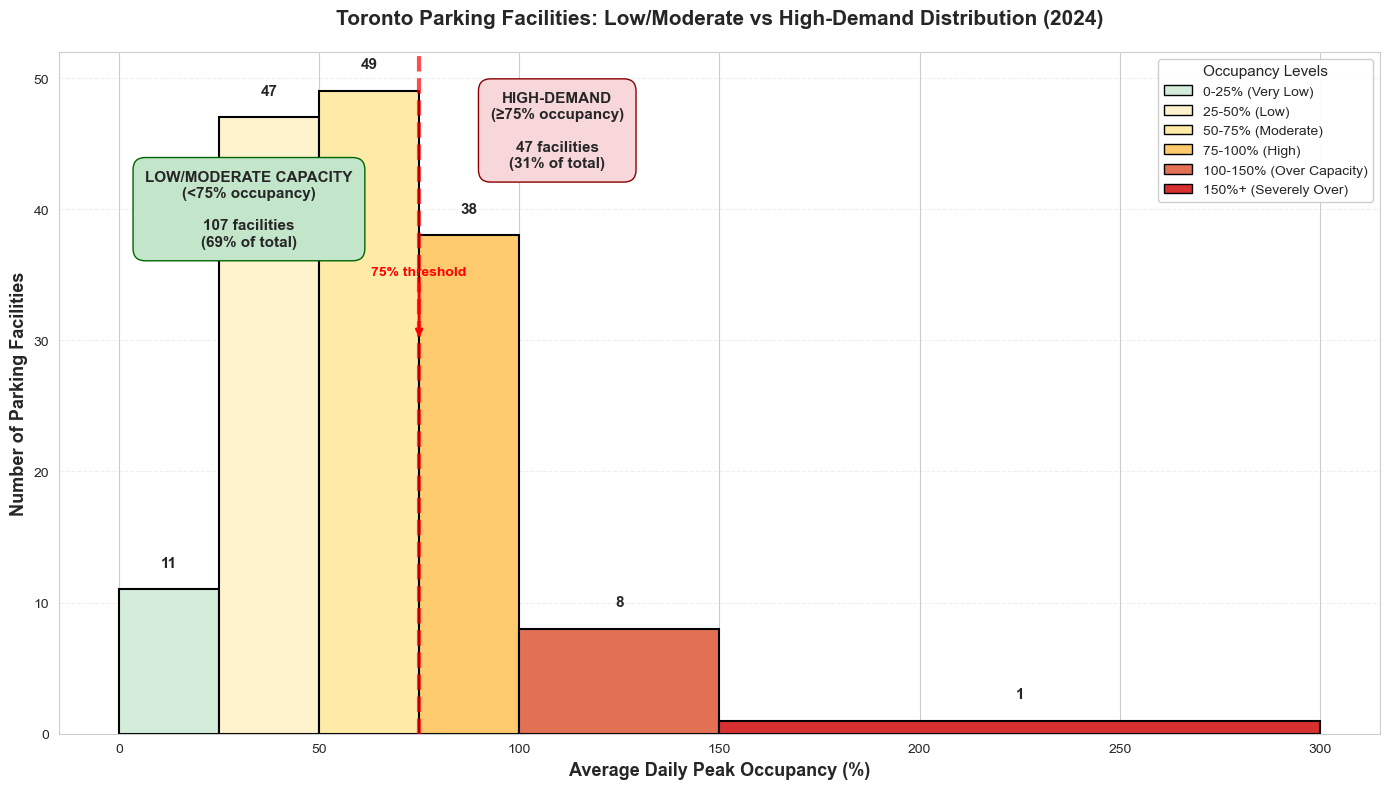

In [80]:
from matplotlib.patches import Patch

# ============================================
# VISUALIZATION: HISTOGRAM
# Distribution of Parking Occupancy Rates
# ============================================

fig, ax = plt.subplots(figsize=(14, 8))

# Create histogram with occupancy categories
occupancy_values = df_2024['avg_peak']

# Create bins
bins = [0, 25, 50, 75, 100, 150, 300]
counts, edges, patches = ax.hist(occupancy_values, bins=bins, 
                                  edgecolor='black', linewidth=1.5)

# Color bars: Green/Yellow for <75%, Orange/Red for ≥75%
colors_low = ['#d4edda', '#fff3cd', '#ffeaa7']  # Green-yellow for low/moderate
colors_high = ['#fdcb6e', '#e17055', '#d63031']  # Orange-red for high-demand

for i, patch in enumerate(patches):
    if i < 3:  # First 3 bins (0-75%)
        patch.set_facecolor(colors_low[i])
    else:  # Last 3 bins (75%+)
        patch.set_facecolor(colors_high[i-3])

# Add value labels on bars
for i, (count, edge) in enumerate(zip(counts, edges[:-1])):
    if count > 0:
        height = count
        center_x = edge + (edges[i+1] - edge)/2
        ax.text(center_x, height + 1.5,
                f'{int(count)}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
        
# Add statistics box
# Customize
ax.set_xlabel('Average Daily Peak Occupancy (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Parking Facilities', fontsize=13, fontweight='bold')
ax.set_title('Toronto Parking Facilities: Low/Moderate vs High-Demand Distribution (2024)', 
             fontsize=15, fontweight='bold', pad=20)

# Add vertical line at 75% to separate categories
ax.axvline(x=75, color='red', linestyle='--', linewidth=3, alpha=0.7)

# Add KEY FINDING boxes with arrows
# Box 1: Low/Moderate capacity
low_mod_pct = (low_moderate / total) * 100
box1_text = f'LOW/MODERATE CAPACITY\n(<75% occupancy)\n\n{low_moderate} facilities\n({low_mod_pct:.0f}% of total)'
ax.text(32.5, 40, box1_text,
        fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#c3e6cb', edgecolor='darkgreen', linewidth=1),
        ha='center', va='center')

# Box 2: High-demand
high_pct = (high_demand / total) * 100
box2_text = f'HIGH-DEMAND\n(≥75% occupancy)\n\n{high_demand} facilities\n({high_pct:.0f}% of total)'
ax.text(109.5, 46, box2_text,
        fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#f8d7da', edgecolor='darkred', linewidth=1),
        ha='center', va='center')

# Add arrow pointing to dividing line
ax.annotate('75% threshold', 
            xy=(75, 30), xytext=(75, 35),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=10, ha='center', color='red', fontweight='bold')

# Legend code (added after the annotation boxes)
legend_elements = [
    Patch(facecolor='#d4edda', edgecolor='black', label='0-25% (Very Low)'),
    Patch(facecolor='#fff3cd', edgecolor='black', label='25-50% (Low)'),
    Patch(facecolor='#ffeaa7', edgecolor='black', label='50-75% (Moderate)'),
    Patch(facecolor='#fdcb6e', edgecolor='black', label='75-100% (High)'),
    Patch(facecolor='#e17055', edgecolor='black', label='100-150% (Over Capacity)'),
    Patch(facecolor='#d63031', edgecolor='black', label='150%+ (Severely Over)')
]

ax.legend(handles=legend_elements, loc='upper right', fontsize=10, 
          title='Occupancy Levels', title_fontsize=11, framealpha=0.95)

ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.set_ylim(bottom=0, top=52)

plt.tight_layout()
plt.savefig('parking_with_findings.png', dpi=300, bbox_inches='tight')
print("\n✓ Histogram saved: Grouped with annotations")
plt.show()

### Second Visualization
#### SCATTER PLOT with Classifications
**Toronto Parking: Facility Size vs Occupancy Classification (2024)**

In [95]:
# Create size categories
def classify_size(spaces):
    if spaces < 50:
        return 'Small (<50)'
    elif spaces < 200:
        return 'Medium (50-200)'
    elif spaces < 500:
        return 'Large (200-500)'
    else:
        return 'Very Large (500+)'

In [96]:
df_2024['size_category'] = df_2024['total_spaces'].apply(classify_size)

In [97]:
# Define outlier thresholds
space_threshold = 500
occ_threshold = 150

# Identify outliers
df_2024['is_outlier'] = (df_2024['total_spaces'] > space_threshold) | (df_2024['avg_peak'] > occ_threshold)
outliers = df_2024[df_2024['is_outlier']]
df_zoomed = df_2024[~df_2024['is_outlier']]

print("DATA SUMMARY:")
print("="*60)
print(f"Total facilities: {len(df_2024)}")
print(f"Outliers: {len(outliers)} ({len(outliers)/len(df_2024)*100:.1f}%)")
print(f"Main cluster (zoomed): {len(df_zoomed)} ({len(df_zoomed)/len(df_2024)*100:.1f}%)")
print("\nOutlier facilities:")
print(outliers[['location', 'total_spaces', 'avg_peak']].sort_values('avg_peak', ascending=False))


DATA SUMMARY:
Total facilities: 154
Outliers: 5 (3.2%)
Main cluster (zoomed): 149 (96.8%)

Outlier facilities:
             location  total_spaces  avg_peak
32  695 Lansdowne Ave            16     249.0
9       37 Queen St E           631      59.0
13     110 Queen St W          1636      34.0
0     20 Charles St E           646      26.0
16        2 Church St          1972      16.0


In [98]:
# ============================================
# REUSABLE SCATTER PLOT FUNCTION
# ============================================

def plot_scatter(ax, data, colors, include_outliers=True, 
                 x_limit=None, y_limit=None, title="", 
                 annotate_extremes=False, show_stats=False):
    """
    Create a scatter plot of parking facility size vs occupancy.
    
    Parameters:
    -----------
    ax : matplotlib axis
        The axis to plot on
    data : DataFrame
        Data to plot (can be full dataset or filtered)
    colors : dict
        Color mapping for size categories
    include_outliers : bool
        Whether to plot outliers with special styling
    x_limit : tuple
        (min, max) for x-axis
    y_limit : tuple
        (min, max) for y-axis
    title : str
        Plot title
    annotate_extremes : bool
        Whether to annotate extreme outliers
    show_stats : bool
        Whether to show statistics box
    """
    
    # Plot regular facilities (non-outliers or all if not distinguishing)
    for category in ['Small (<50)', 'Medium (50-200)', 'Large (200-500)', 'Very Large (500+)']:
        if include_outliers:
            # For full view: plot non-outliers as regular dots
            data_subset = data[(data['size_category'] == category) & (~data['is_outlier'])]
        else:
            # For zoomed view: plot all data (already filtered)
            data_subset = data[data['size_category'] == category]
        
        if len(data_subset) > 0:
            marker_size = 100 if include_outliers else 120
            alpha = 0.6 if include_outliers else 0.7
            ax.scatter(data_subset['total_spaces'], data_subset['avg_peak'], 
                      c=colors[category],
                      s=marker_size, alpha=alpha, edgecolors='black', linewidth=0.5)
    
    # Plot outliers with special styling (only for full view)
    if include_outliers:
        for category in ['Small (<50)', 'Medium (50-200)', 'Large (200-500)', 'Very Large (500+)']:
            data_outlier = data[(data['size_category'] == category) & (data['is_outlier'])]
            if len(data_outlier) > 0:
                ax.scatter(data_outlier['total_spaces'], data_outlier['avg_peak'], 
                          c=colors[category],
                          s=200, alpha=0.9, edgecolors='red', linewidth=3, 
                          marker='D')  # Diamond shape
        
        # Annotate extreme outliers
        if annotate_extremes and len(outliers) > 0:
            extreme_outliers = [
                outliers.loc[outliers['avg_peak'].idxmax()],  # Highest occupancy
                outliers.loc[outliers['total_spaces'].idxmax()]  # Largest facility
            ]
            
            for idx, outlier in enumerate(extreme_outliers):
                ax.annotate(f"{outlier['location']}\n({outlier['total_spaces']:.0f} spaces, {outlier['avg_peak']:.0f}%)",
                           xy=(outlier['total_spaces'], outlier['avg_peak']),
                           xytext=(outlier['total_spaces'] + 200, outlier['avg_peak'] + 30) if idx == 0 
                                  else (outlier['total_spaces'] - 300, outlier['avg_peak'] + 50),
                           arrowprops=dict(arrowstyle='->', color='red', lw=2),
                           fontsize=8, ha='center',
                           bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', 
                                   edgecolor='red', linewidth=2, alpha=0.9))
    
    # Add threshold lines
    if include_outliers or y_limit[1] > 50:
        ax.axhline(y=50, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.axhline(y=75, color='red', linestyle='--', linewidth=2, alpha=0.7)
    ax.axhline(y=100, color='darkred', linestyle='--', linewidth=2, alpha=0.7)
    
    # Customize plot
    ax.set_xlabel('Total Available Spaces (Facility Size)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Average Daily Peak Occupancy (%)', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    
    # Set axis limits
    if x_limit:
        ax.set_xlim(x_limit)
    if y_limit:
        ax.set_ylim(y_limit)
    
    # Add annotations
    if include_outliers:
        # Outlier warning box
        outlier_text = f'⚠️ {len(outliers)} Outliers\n(>{space_threshold} spaces OR\n>{occ_threshold}% occupancy)'
        ax.text(0.98, 0.98, outlier_text,
               transform=ax.transAxes, fontsize=10, fontweight='bold',
               verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='lightyellow', 
                        edgecolor='red', linewidth=2, alpha=0.9))
    
    if show_stats:
        # Statistics box
        stats_text = f'Main Cluster Stats:\nAvg Occupancy: {data["avg_peak"].mean():.1f}%\nMedian: {data["avg_peak"].median():.1f}%\nRange: {data["avg_peak"].min():.0f}-{data["avg_peak"].max():.0f}%'
        ax.text(0.98, 0.02, stats_text,
               transform=ax.transAxes, fontsize=9,
               verticalalignment='bottom', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

C:\Users\Suha\AppData\Local\Temp\ipykernel_31576\1668609243.py:77: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0.05, 1, 0.96])
C:\Users\Suha\AppData\Local\Temp\ipykernel_31576\1668609243.py:77: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0.05, 1, 0.96])
C:\Users\Suha\AppData\Local\Temp\ipykernel_31576\1668609243.py:78: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig('parking_scatter_sidebyside.png', dpi=300, bbox_inches='tight')
C:\Users\Suha\AppData\Local\Temp\ipykernel_31576\1668609243.py:78: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.savefig('parking_scatter_sidebyside.png', dpi=300, bbox_inches='tight')



✓ Side-by-side scatter plot saved!


c:\Users\Suha\miniconda3\envs\dsi_suha\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Suha\miniconda3\envs\dsi_suha\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


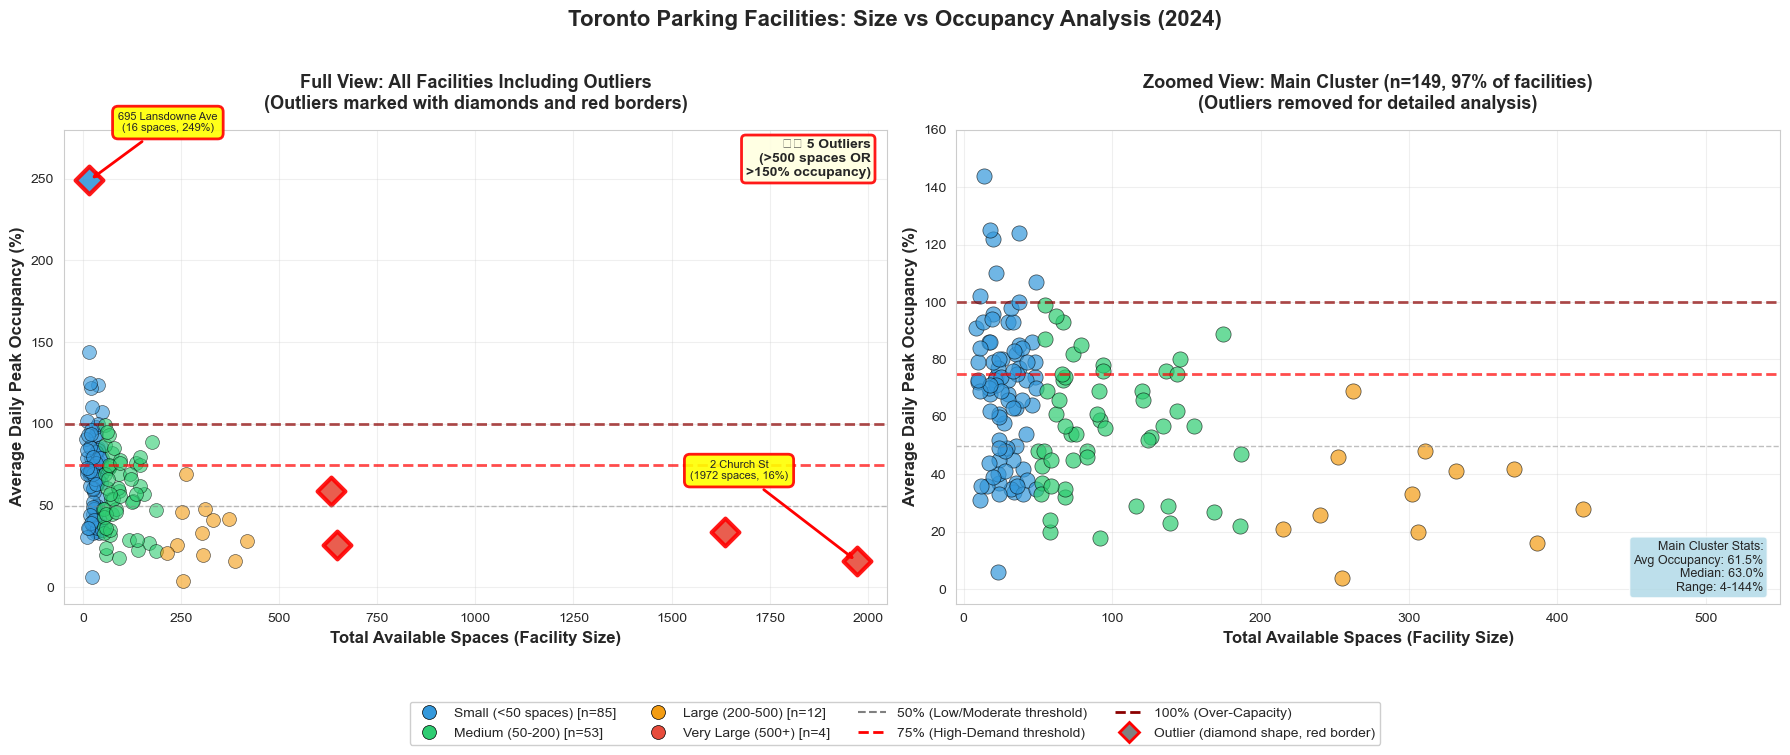

In [102]:
# ============================================
# CREATE SIDE-BY-SIDE PLOTS USING FUNCTION
# ============================================
from matplotlib.lines import Line2D

sns.set_style("whitegrid")

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Define colors
colors = {
    'Small (<50)': '#3498db',
    'Medium (50-200)': '#2ecc71',
    'Large (200-500)': '#f39c12',
    'Very Large (500+)': '#e74c3c'
}

# LEFT PLOT: Full view with outliers
plot_scatter(
    ax=ax1,
    data=df_2024,
    colors=colors,
    include_outliers=True,
    x_limit=(-50, 2050),
    y_limit=(-10, 280),
    title='Full View: All Facilities Including Outliers\n(Outliers marked with diamonds and red borders)',
    annotate_extremes=True,
    show_stats=False
)

# RIGHT PLOT: Zoomed view without outliers
plot_scatter(
    ax=ax2,
    data=df_zoomed,
    colors=colors,
    include_outliers=False,
    x_limit=(-5, space_threshold + 50),
    y_limit=(-5, occ_threshold + 10),
    title=f'Zoomed View: Main Cluster (n={len(df_zoomed)}, {len(df_zoomed)/len(df_2024)*100:.0f}% of facilities)\n(Outliers removed for detailed analysis)',
    annotate_extremes=False,
    show_stats=True
)

# ============================================
# SHARED LEGEND
# ============================================

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['Small (<50)'], 
           markersize=10, label=f"Small (<50 spaces) [n={len(df_2024[df_2024['size_category']=='Small (<50)'])}]", 
           markeredgecolor='black', markeredgewidth=0.5),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['Medium (50-200)'], 
           markersize=10, label=f"Medium (50-200) [n={len(df_2024[df_2024['size_category']=='Medium (50-200)'])}]", 
           markeredgecolor='black', markeredgewidth=0.5),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['Large (200-500)'], 
           markersize=10, label=f"Large (200-500) [n={len(df_2024[df_2024['size_category']=='Large (200-500)'])}]", 
           markeredgecolor='black', markeredgewidth=0.5),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['Very Large (500+)'], 
           markersize=10, label=f"Very Large (500+) [n={len(df_2024[df_2024['size_category']=='Very Large (500+)'])}]", 
           markeredgecolor='black', markeredgewidth=0.5),
    Line2D([0], [0], color='gray', linestyle='--', linewidth=1.5, label='50% (Low/Moderate threshold)'),
    Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='75% (High-Demand threshold)'),
    Line2D([0], [0], color='darkred', linestyle='--', linewidth=2, label='100% (Over-Capacity)'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='gray', 
           markersize=10, label='Outlier (diamond shape, red border)', 
           markeredgecolor='red', markeredgewidth=2),
]

fig.legend(handles=legend_elements, loc='lower center', ncol=4, 
          fontsize=10, framealpha=0.95, bbox_to_anchor=(0.5, -0.08))

# Overall title
fig.suptitle('Toronto Parking Facilities: Size vs Occupancy Analysis (2024)', 
            fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.savefig('parking_scatter_sidebyside.png', dpi=300, bbox_inches='tight')
print("\n✓ Side-by-side scatter plot saved!")
plt.show()

In [103]:
# ============================================
# ANALYSIS OUTPUT
# ============================================

print("\n" + "="*60)
print("ANALYSIS FOR ASSIGNMENT QUESTIONS:")
print("="*60)

print("\n1. OUTLIER INSIGHTS (Left Plot):")
print(f"   - {len(outliers)} facilities require special attention")
print(f"   - Highest occupancy: {outliers['avg_peak'].max():.0f}% at {outliers.loc[outliers['avg_peak'].idxmax(), 'location']}")
print(f"   - Largest facility: {outliers['total_spaces'].max():.0f} spaces at {outliers.loc[outliers['total_spaces'].idxmax(), 'location']}")
print(f"   - Over-capacity outliers: {len(outliers[outliers['avg_peak'] > 100])}")

print("\n2. MAIN CLUSTER PATTERNS (Right Plot):")
print(f"   - {len(df_zoomed)} facilities ({len(df_zoomed)/len(df_2024)*100:.0f}%) in typical range")
print(f"   - Average occupancy: {df_zoomed['avg_peak'].mean():.1f}%")
print(f"   - High-demand (≥75%): {len(df_zoomed[df_zoomed['avg_peak'] >= 75])} facilities")
print(f"   - Underutilized (<30%): {len(df_zoomed[df_zoomed['avg_peak'] < 30])} facilities")

print("\n3. SIZE-OCCUPANCY RELATIONSHIP:")
all_corr = df_2024['total_spaces'].corr(df_2024['avg_peak'])
zoomed_corr = df_zoomed['total_spaces'].corr(df_zoomed['avg_peak'])
print(f"   - All facilities: {all_corr:.3f}")
print(f"   - Main cluster only: {zoomed_corr:.3f}")
print("   → Larger facilities tend to have LOWER occupancy")

print("\n4. KEY TAKEAWAY:")
print("   The dual-view approach reveals:")
print("   - Extreme cases need policy intervention (left plot)")
print("   - Most facilities follow predictable patterns (right plot)")
print("   - Government should address both outliers AND optimize main cluster")


ANALYSIS FOR ASSIGNMENT QUESTIONS:

1. OUTLIER INSIGHTS (Left Plot):
   - 5 facilities require special attention
   - Highest occupancy: 249% at 695 Lansdowne Ave
   - Largest facility: 1972 spaces at 2 Church St
   - Over-capacity outliers: 1

2. MAIN CLUSTER PATTERNS (Right Plot):
   - 149 facilities (97%) in typical range
   - Average occupancy: 61.5%
   - High-demand (≥75%): 46 facilities
   - Underutilized (<30%): 15 facilities

3. SIZE-OCCUPANCY RELATIONSHIP:
   - All facilities: -0.281
   - Main cluster only: -0.390
   → Larger facilities tend to have LOWER occupancy

4. KEY TAKEAWAY:
   The dual-view approach reveals:
   - Extreme cases need policy intervention (left plot)
   - Most facilities follow predictable patterns (right plot)
   - Government should address both outliers AND optimize main cluster
